In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/clean_nav.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
perf = pd.read_csv("../data/processed/clean_performance.csv")
nav['date'] = pd.to_datetime(nav['date'])

# Select 5 funds - top 5 by AUM
top5_codes = perf.nlargest(5, 'aum_crore')['amfi_code'].tolist()
top5_names = fund[fund['amfi_code'].isin(top5_codes)].set_index('amfi_code')['scheme_name'].to_dict()

print("Selected 5 funds:")
for code in top5_codes:
    print(f"  {code}: {top5_names[code]}")

Selected 5 funds:
  148568: Mirae Asset Emerging Bluechip Fund - Regular - Growth
  120842: Kotak Emerging Equity Fund - Regular - Growth
  118634: Nippon India Small Cap Fund - Regular - Growth
  149322: DSP Top 100 Equity Fund - Regular - Growth
  102886: UTI Mid Cap Fund - Regular - Growth


In [2]:
# Pivot NAV to get returns for each fund
nav_pivot = nav[nav['amfi_code'].isin(top5_codes)].pivot_table(
    index='date', columns='amfi_code', values='nav')

returns = nav_pivot.pct_change().dropna()
returns.columns = [top5_names[c][:20] for c in returns.columns]

print("Returns shape:", returns.shape)
print("\nAnnualized Returns:")
print((returns.mean() * 252 * 100).round(2))
print("\nAnnualized Volatility:")
print((returns.std() * np.sqrt(252) * 100).round(2))

Returns shape: (1149, 5)

Annualized Returns:
UTI Mid Cap Fund - R     2.77
Nippon India Small C    17.82
Kotak Emerging Equit     7.86
Mirae Asset Emerging    20.79
DSP Top 100 Equity F    13.16
dtype: float64

Annualized Volatility:
UTI Mid Cap Fund - R    18.13
Nippon India Small C    25.24
Kotak Emerging Equit    17.89
Mirae Asset Emerging    15.43
DSP Top 100 Equity F    14.35
dtype: float64


In [4]:
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

n_portfolios = 10000
n_assets = len(top5_codes)

results = np.zeros((3, n_portfolios))
weights_record = []

np.random.seed(42)

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    results[0, i] = portfolio_return
    results[1, i] = portfolio_std
    results[2, i] = portfolio_return / portfolio_std  # Sharpe ratio (Rf=0 for simplicity)

print(f"Generated {n_portfolios} random portfolios")
print(f"Return range: {results[0].min():.2%} to {results[0].max():.2%}")
print(f"Risk range: {results[1].min():.2%} to {results[1].max():.2%}")

Generated 10000 random portfolios
Return range: 5.56% to 18.78%
Risk range: 7.79% to 19.02%


In [5]:
# Max Sharpe Ratio portfolio
max_sharpe_idx = results[2].argmax()
max_sharpe_weights = weights_record[max_sharpe_idx]

# Min Volatility portfolio
min_vol_idx = results[1].argmin()
min_vol_weights = weights_record[min_vol_idx]

print("Maximum Sharpe Ratio Portfolio:")
print(f"  Return: {results[0, max_sharpe_idx]:.2%}, Risk: {results[1, max_sharpe_idx]:.2%}, Sharpe: {results[2, max_sharpe_idx]:.2f}")
for name, w in zip(returns.columns, max_sharpe_weights):
    print(f"  {name}: {w:.1%}")

print("\nMinimum Volatility Portfolio:")
print(f"  Return: {results[0, min_vol_idx]:.2%}, Risk: {results[1, min_vol_idx]:.2%}, Sharpe: {results[2, min_vol_idx]:.2f}")
for name, w in zip(returns.columns, min_vol_weights):
    print(f"  {name}: {w:.1%}")

Maximum Sharpe Ratio Portfolio:
  Return: 15.74%, Risk: 8.68%, Sharpe: 1.81
  UTI Mid Cap Fund - R: 4.0%
  Nippon India Small C: 12.0%
  Kotak Emerging Equit: 13.8%
  Mirae Asset Emerging: 41.5%
  DSP Top 100 Equity F: 28.7%

Minimum Volatility Portfolio:
  Return: 12.87%, Risk: 7.79%, Sharpe: 1.65
  UTI Mid Cap Fund - R: 17.3%
  Nippon India Small C: 10.7%
  Kotak Emerging Equit: 18.0%
  Mirae Asset Emerging: 25.8%
  DSP Top 100 Equity F: 28.1%


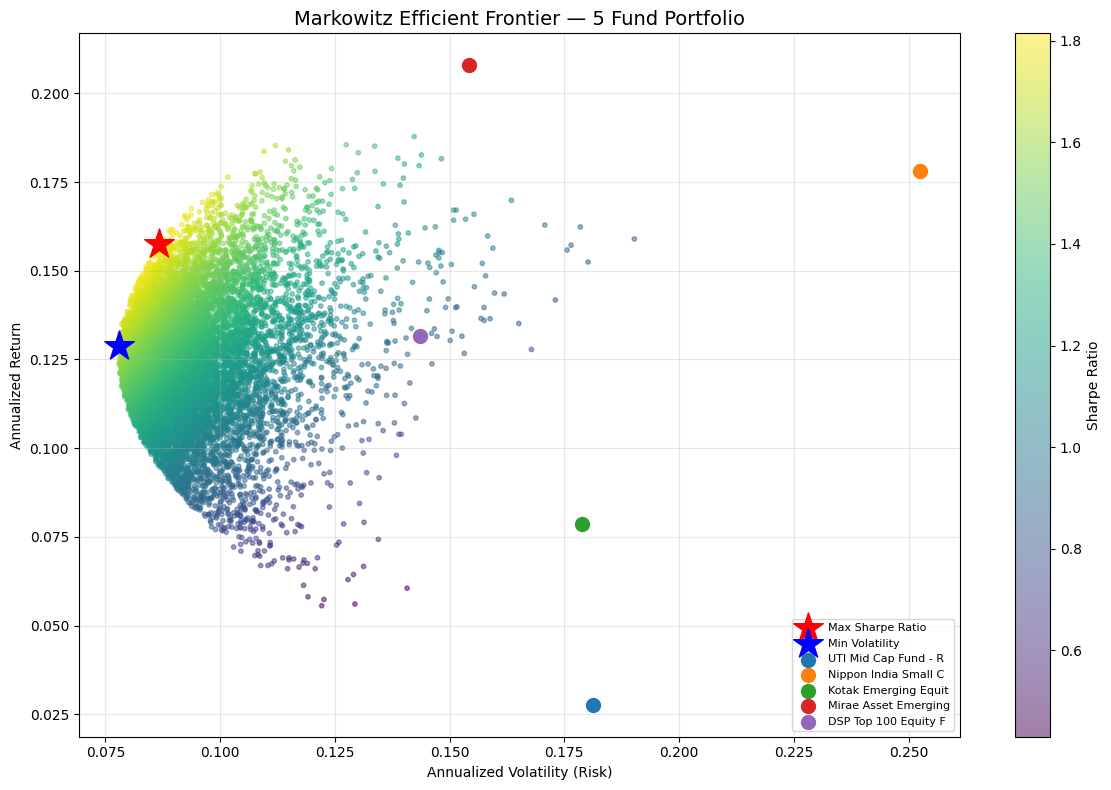

In [6]:
plt.figure(figsize=(12, 8))

# Plot all random portfolios
scatter = plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Mark max Sharpe portfolio
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], 
            color='red', marker='*', s=500, label='Max Sharpe Ratio')

# Mark min volatility portfolio
plt.scatter(results[1, min_vol_idx], results[0, min_vol_idx], 
            color='blue', marker='*', s=500, label='Min Volatility')

# Mark individual assets
for i, name in enumerate(returns.columns):
    plt.scatter(np.sqrt(cov_matrix.iloc[i, i]), mean_returns.iloc[i], 
                marker='o', s=100, label=name)

plt.title('Markowitz Efficient Frontier — 5 Fund Portfolio', fontsize=14)
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/charts/efficient_frontier.png")
plt.show()

In [7]:
optimal_portfolios = pd.DataFrame({
    'fund': returns.columns,
    'max_sharpe_weight_pct': (max_sharpe_weights * 100).round(2),
    'min_vol_weight_pct': (min_vol_weights * 100).round(2)
})

optimal_portfolios.to_csv("../data/processed/efficient_frontier_portfolios.csv", index=False)
print(optimal_portfolios)

                   fund  max_sharpe_weight_pct  min_vol_weight_pct
0  UTI Mid Cap Fund - R                   4.01               17.32
1  Nippon India Small C                  12.00               10.68
2  Kotak Emerging Equit                  13.77               18.04
3  Mirae Asset Emerging                  41.55               25.84
4  DSP Top 100 Equity F                  28.67               28.12


## Markowitz Efficient Frontier — Key Insights

A portfolio optimization analysis was performed on 5 mid/small-cap 
equity funds using 10,000 randomly generated portfolio weight 
combinations to map the risk-return tradeoff space.

**Maximum Sharpe Ratio Portfolio** (Sharpe: 1.81) achieves 15.74% 
annualized return at 8.68% risk, with Mirae Asset Emerging Bluechip 
Fund (41.5%) and DSP Top 100 Equity Fund (28.7%) as the largest 
allocations — favoring funds with the best risk-adjusted historical 
performance.

**Minimum Volatility Portfolio** (Sharpe: 1.65) reduces risk to 7.79% 
at the cost of slightly lower returns (12.87%), achieved through more 
balanced allocation across all 5 funds.

This demonstrates the core principle of Modern Portfolio Theory: 
diversification across funds with different risk-return profiles can 
improve the overall portfolio's risk-adjusted return compared to 
holding any single fund.